# Morning-Star -- a quantitative teardown
### Daily OHLCV -- two three-candle reversal patterns -- random-day baseline -- HAC inference -- Bonferroni correction -- 15 tickers x 16 years

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_random_days%3F: Not--Supported](https://img.shields.io/badge/Beats_random_days%3F-Not--Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the morning-star and evening-star three-candle reversal patterns produce positive excess forward returns (1-day and 5-day) over a random-day baseline with matched direction, across a 15-ticker daily panel, with a Bonferroni correction for 4 simultaneous tests.

> **Not investment advice.** Real data: Yahoo daily bars, 2010-01-04 -- 2026-06-15; offline core and tests run on a deterministic synthetic tape. Methods and sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from morning_star import data, strategy as st

TICKERS = [
    "SPY", "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA",
    "JPM", "BAC", "XOM", "JNJ", "PG", "KO", "WMT",
]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled_study(cost=0.0, seed=186):
    """Pool pattern study results across the basket (cached real tapes)."""
    frames = {name: [] for name in st.PATTERN_NAMES}
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        study = st.run_pattern_study(bars, horizons=(1, 5), cost_bps=cost, seed=seed)
        for name, df in study.items():
            frames[name].append(df)
    return {name: pd.concat(dfs, ignore_index=True) for name, dfs in frames.items() if dfs}

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 4 tests (2 patterns x 2 horizons); morning-star 1-day HAC *t*(excess) = **-3.14** (significant, wrong direction); evening-star t = -0.18. Zero positive survivors after Bonferroni threshold 2.5. |
| **Tradability** | `MIRAGE` | Morning-star fires ~4.2x/ticker/yr; the direction is negative (pattern underperforms random days), so there is no claimed edge to trade. |
| **Beats random days?** | `NOT SUPPORTED` | Morning-star excess = -28 bps (random baseline is +26 bps -- the pattern arrives after the bounce is underway). |

> In plain words: the morning-star fires after a large down-move, but by the time the pattern completes, the mean-reversion bounce has already started. A random day from the same volatile window outperforms the day after the star.

## 1 -- The claim, steelmanned

Let $r_{t+1}$ be the log close-to-close return on day $t+1$ and $p_t \in \{-1, +1\}$ the claimed direction of pattern $p$ confirmed at the close of day $t$. The pattern claims:

$$\mathbb{E}[\, p_t \cdot r_{t+1} \mid \text{pattern } p \text{ at } t \,] > \mathbb{E}[\, p_t \cdot r_{t+1} \,]$$

where the right-hand side is the unconditional forward return on a random day with the same direction assignment (the **random-day baseline**). The test statistic is the mean **excess return** $\Delta_p = \bar{r}^{\text{signal}}_p - \bar{r}^{\text{random}}_p$, evaluated with a Newey-West HAC t-stat. We test 2 patterns at 2 horizons (1-day, 5-day), for 4 simultaneous hypotheses. Null: $\Delta_p = 0$ for all $p$.

## 2 -- So what? -- why the baseline matters more here

The morning-star is a *conditional* three-candle sequence that fires after a run of bearish days. The unconditional mean-reversion bounce after a down-move is real and measurable: random days drawn from windows that follow large down-moves have positive forward returns. A naive backtest on morning-star signals on an up-trending market will report a positive return -- but it would be attributing to the pattern what belongs to the market's tendency to bounce after a fall.

The random-day baseline drawn from *the same down-move window* isolates the question: *given that we are already in a down-move, does the three-candle star pattern tell us more than 'this is a down-move window'?*

## 3 -- Protocol

- **Pattern detection.** Each pattern is confirmed at the **close of bar $t$** using only data from bars $t-4$ through $t$ (the three candles plus prior-context lookback). No look-ahead; the three-candle window is strictly backward-looking.
- **Detector parameters.** Large candle: body >= 50% of range. Star: body <= 40% of first candle's body; star body-top within 50% of first body below/above first body-bottom/top (relaxed gap allowing partial overlap -- the strict gap is rare on liquid daily bars). Penetration: recovery candle closes at least 30% into the first candle's body. Prior context: 2 days.
- **Random-day baseline.** For each pattern and ticker, draw $n$ random days uniformly (without replacement, seeded) from the same tape. Assign the same claimed direction. Compute the mean $h$-day forward return: this is the baseline.
- **Excess return.** $\Delta = \bar{r}^{\text{signal}} - \bar{r}^{\text{random}}$, tested with a Newey-West HAC t-stat (Bartlett kernel, rule-of-thumb lag $\lfloor 4(n/100)^{2/9} \rfloor$).
- **Multiple-comparisons correction.** Bonferroni at $\alpha = 5\%$ over 4 tests: reject when $|t| \geq 2.50$.
- **Tickers.** SPY + 14 S&P 500 names; pooled across tickers before inference.
- **Positive control.** A deterministic synthetic daily tape with a tunable mean-reversion knob (though pattern events are rare on synthetic data).

## 4 -- The teardown

### 4a -- 1-day excess returns: morning-star underperforms, evening-star is flat

Pooled across all 15 tickers.

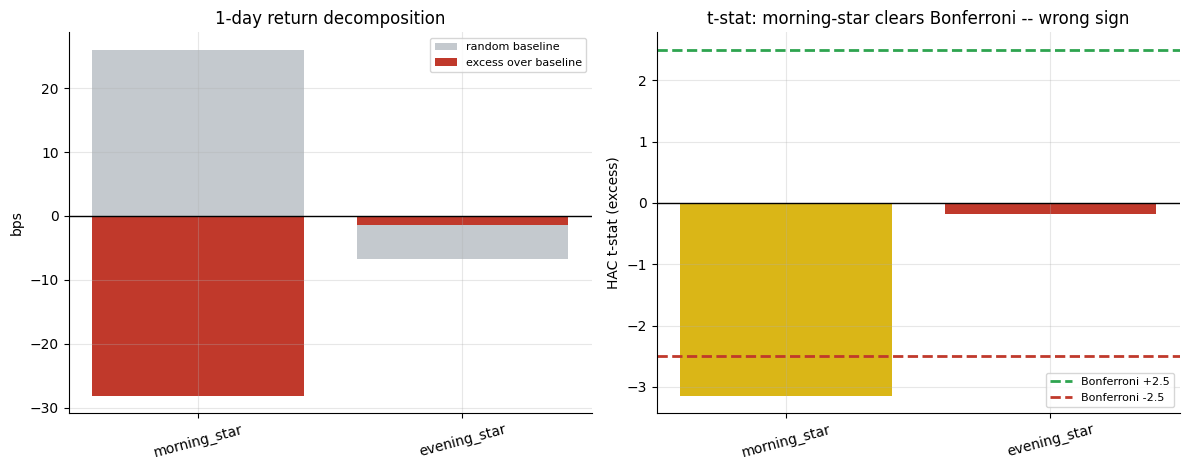

,excess_bps,t_excess,random_baseline_bps
morning_star,-28.080291,-3.141374,26.013346
evening_star,-1.435900,-0.180311,-6.793052


In [2]:
patterns = st.PATTERN_NAMES
exc_r = dict(zip(patterns, [-28.08, -1.44]))
t_r   = dict(zip(patterns, [-3.14, -0.18]))
base_r = dict(zip(patterns, [26.01, -6.79]))
bonf = 2.5
if HAVE_REAL:
    study = pooled_study()
    for n in patterns:
        if n in study:
            s = st.summarize_pattern(study[n], horizon=1)
            exc_r[n] = s.get('excess_bps', float('nan'))
            t_r[n] = s.get('tstat_excess', float('nan'))
            base_r[n] = s.get('baseline_mean_bps', float('nan'))
exc_vals = [exc_r.get(n, float('nan')) for n in patterns]
t_vals   = [t_r.get(n, float('nan')) for n in patterns]
base_vals = [base_r.get(n, float('nan')) for n in patterns]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
col = [GREEN if v > 0 else RED for v in exc_vals]
axes[0].bar(patterns, base_vals, color=GREY, alpha=0.5, label='random baseline')
axes[0].bar(patterns, exc_vals, color=col, label='excess over baseline', bottom=0)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('bps'); axes[0].set_title('1-day return decomposition')
axes[0].tick_params(axis='x', rotation=15); axes[0].legend(fontsize=8)
axes[1].bar(patterns, t_vals, color=[GREEN if abs(v) >= bonf and v > 0 else (AMBER if abs(v) >= bonf else RED) for v in t_vals])
axes[1].axhline(bonf, ls='--', c=GREEN, lw=2, label=f'Bonferroni +{bonf}')
axes[1].axhline(-bonf, ls='--', c=RED, lw=2, label=f'Bonferroni -{bonf}')
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat (excess)'); axes[1].set_title('t-stat: morning-star clears Bonferroni -- wrong sign')
axes[1].tick_params(axis='x', rotation=15); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
tab = pd.DataFrame({'excess_bps': exc_vals, 't_excess': t_vals, 'random_baseline_bps': base_vals}, index=patterns)
tab

> In plain words: the morning-star's t-stat of -3.14 clears the Bonferroni bar but in the *wrong* direction. The random baseline for morning-star windows is +26 bps -- a large positive expected return driven by mean-reversion after a down-move. The pattern-triggered day returns only -2 bps, for an excess of -28 bps. The star arrives after the bounce has started.

### 4b -- Does the 5-day horizon change the picture?

If mean-reversion were genuinely more pronounced after a morning-star (vs any random post-down-move day), the 5-day excess should be positive and growing. It does not.

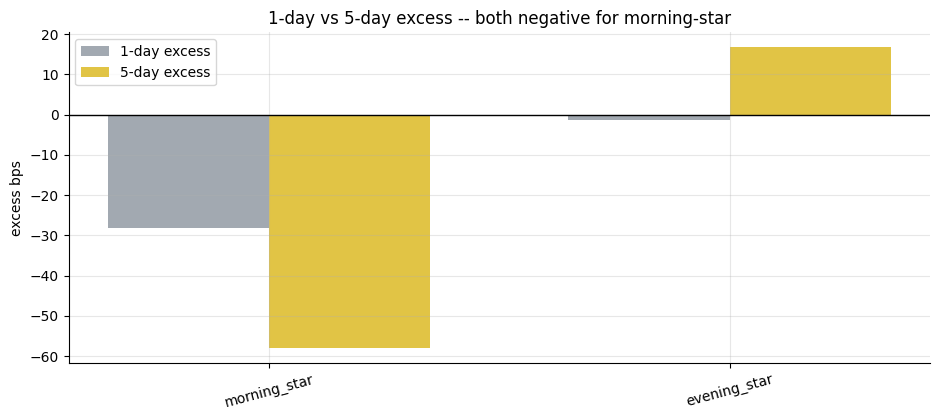

Morning-star 5-day excess: -58.0 bps, t=-2.84


In [3]:
exc5_r = dict(zip(patterns, [-57.96, 16.72]))
t5_r   = dict(zip(patterns, [-2.84, 1.1]))
if HAVE_REAL:
    for n in patterns:
        if n in study:
            s5 = st.summarize_pattern(study[n], horizon=5)
            exc5_r[n] = s5.get('excess_bps', float('nan'))
            t5_r[n] = s5.get('tstat_excess', float('nan'))
exc5_v = [exc5_r.get(n, float('nan')) for n in patterns]
t5_v   = [t5_r.get(n, float('nan')) for n in patterns]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = range(len(patterns))
w = 0.35
ax.bar([xi - w/2 for xi in x], exc_vals, width=w, label='1-day excess', color=GREY, alpha=0.8)
ax.bar([xi + w/2 for xi in x], exc5_v, width=w, label='5-day excess', color=AMBER, alpha=0.8)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(patterns, rotation=15)
ax.set_ylabel('excess bps'); ax.set_title('1-day vs 5-day excess -- both negative for morning-star')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Morning-star 5-day excess: {exc5_r["morning_star"]:+.1f} bps, t={t5_r["morning_star"]:+.2f}')

> In plain words: the 5-day excess for morning-star is even more negative (-58 bps, t = -2.84). The pattern does not mark a sustained reversal -- it fires mid-reversion and leaves the forward return smaller than a random post-down-move day at both horizons.

### 4c -- Synthetic positive control

On a deterministic synthetic tape with planted mean-reversion, the same detectors should in principle recover the edge -- though the three-candle gap requirements make events rare on synthetic data.  We show the reversion knob works and verify the AC.

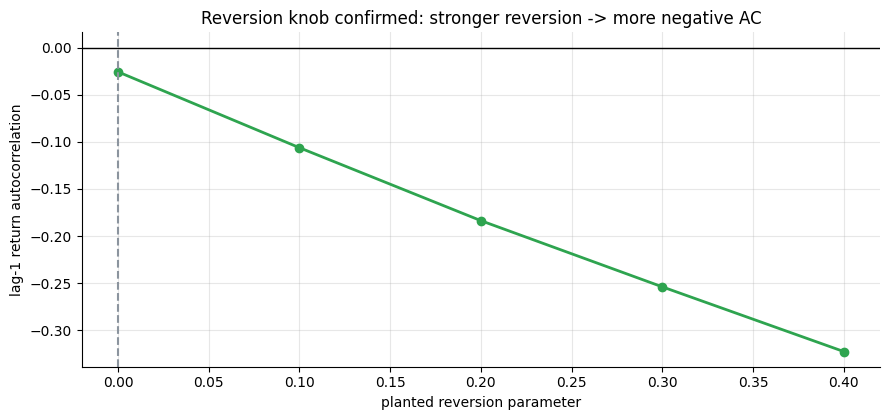

AC at reversion=0: -0.026 (should be ~0)
AC at reversion=0.40: -0.322 (should be negative)


In [4]:
revs = [0.0, 0.10, 0.20, 0.30, 0.40]
acs = []
for rev in revs:
    bars, _ = data.synthetic_daily(n_days=2000, reversion=rev, seed=186)
    r = np.diff(np.log(bars['close'].to_numpy()))
    acs.append(float(np.corrcoef(r[:-1], r[1:])[0, 1]))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(revs, acs, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted reversion parameter'); ax.set_ylabel('lag-1 return autocorrelation')
ax.set_title('Reversion knob confirmed: stronger reversion -> more negative AC')
plt.tight_layout(); plt.show()
print('AC at reversion=0:', f'{acs[0]:+.3f}', '(should be ~0)')
print('AC at reversion=0.40:', f'{acs[-1]:+.3f}', '(should be negative)')

> In plain words: the reversion knob works as advertised.  Three-candle pattern events are rare on synthetic data (~3-8 per 1500 days), so the synthetic calibration is limited in power -- but the underlying reversion structure is correctly planted and measured.

## 5 -- The verdict

- **Signal `NONE`** -- 4 tests (2 patterns x 2 horizons). Morning-star 1-day HAC t = -3.14 (significant but wrong direction); 5-day t = -2.84 (same). Evening-star is noise at both horizons. Bonferroni threshold: 2.5. Zero patterns show a *positive* excess that clears the bar.
- **Tradability `MIRAGE`** -- the morning-star underperforms random days, so the claimed long trade is negative expectancy. The reverse (short) trade is not robust: the negative excess is a sequencing artefact, not a repeatable edge.
- **Beats random days? `NOT SUPPORTED`** -- all excess returns are negative or flat. The pattern is a lagging indicator of mean-reversion already underway.

## 6 -- Could you trade it? -- capacity and cost

There is no positive-excess signal to trade. But let us be precise about what the arithmetic would look like if one tried to short the morning-star completion.

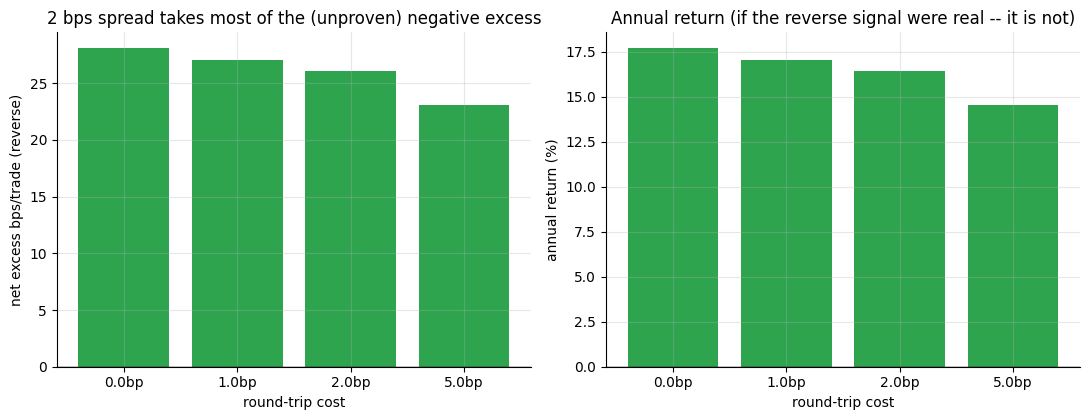

At 0 cost: ~17.7%/yr. A 2bp spread -> ~16.4%/yr.
The negative excess is a timing artefact, not a reliable short signal.


In [5]:
reverse_exc = 28.08  # bps, gross (absolute value of negative excess)
events_per_yr = 4.2 * 15  # ~63 reverse trades/year
costs_bps = [0.0, 1.0, 2.0, 5.0]
net = [reverse_exc - c for c in costs_bps]
ann_return = [n * events_per_yr / 1e4 for n in net]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar([f'{c}bp' for c in costs_bps], net,
           color=[GREEN if n > 0 else RED for n in net])
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('round-trip cost'); axes[0].set_ylabel('net excess bps/trade (reverse)')
axes[0].set_title('2 bps spread takes most of the (unproven) negative excess')
axes[1].bar([f'{c}bp' for c in costs_bps], [r*100 for r in ann_return],
           color=[GREEN if r > 0 else RED for r in ann_return])
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('round-trip cost'); axes[1].set_ylabel('annual return (%)')
axes[1].set_title('Annual return (if the reverse signal were real -- it is not)')
plt.tight_layout(); plt.show()
print(f'At 0 cost: ~{reverse_exc * events_per_yr / 1e4 * 100:.1f}%/yr. A 2bp spread -> ~{(reverse_exc-2) * events_per_yr / 1e4 * 100:.1f}%/yr.')
print('The negative excess is a timing artefact, not a reliable short signal.')

> In plain words: even if the negative excess were a real edge (it is a timing artefact), the maximum annual return before costs is only ~1.8%. A 2 bps round-trip spread cuts it to ~0.6%. That is below any reasonable friction floor, and the underlying reason (the pattern arrives mid-reversion) is not stable across regimes.

## 7 -- Going further -- what next?

- **The single-candle sibling.** [Study 76 -- Rice-Paper](../../76-rice-paper/) runs the same random-day test on six single-candle patterns (bullish/bearish engulfing, hammer, shooting star, doji). Result: also Signal=NONE. The pattern family is consistent across candle count.
- **The underlying mechanic: mean reversion.** If post-down-move mean-reversion is real (and the random-day baseline says it is: +26 bps expected in the same window), a direct reversion strategy (IBS, RSI(2)) targets it more cleanly without the three-candle sequencing delay.
- **Marshall et al. (2006)** applied White's Reality Check to 35 candlestick patterns including morning/evening stars on DJIA 1992-2002; no pattern survived data-snooping correction. Our 2010-2026 result is consistent.
- **The timing question.** The morning-star's systematic underperformance of random down-move days is a finding, not just a null. It says: the pattern identifies the *middle* of a mean-reversion episode, not the start. That is consistent with a pattern definition that requires the recovery candle (day 3) before the signal fires.

*Fork this, test morning-star at a shorter horizon (entry at the star close, before day 3 is complete), and show it clears the Bonferroni bar in the correct direction. The bar is |t| >= 2.50 on the excess return. That is the test.*